# 09. Análisis de Errores del Modelo Híbrido

**Objetivo:** caracterizar errores por clase y generar evidencia cualitativa/cuantitativa para la discusión metodológica.
**Entradas (inputs):** `data/outputs/cierre_modelos_dev_<timestamp>/decision_modelo_final.json`, `ranking_modelos_dev.csv`, predicciones del `train_<run_id>` de referencia y `data/splits/dataset_base.csv`.
**Salidas (outputs):** `data/outputs/error_analysis_<run_id>/resumen_error_por_clase.csv`, `matriz_confusion.csv`, `terminos_distintivos_errores.csv`, `casos_mal_clasificados.csv`, `resumen_error_analysis.json`.
**Notebook anterior:** `notebooks/pipeline/09b_cierre_modelos_dev.ipynb`.
**Notebook siguiente:** fase clínica externa opcional (`notebooks/analysis/10_validacion_clinica_ips.ipynb`).


## Técnicas, herramientas y librerías de esta etapa

- **Técnica principal:** análisis descriptivo de errores del modelo final congelado.
- **Herramientas/librerías:** `pandas`, `matplotlib`, `CountVectorizer` de `scikit-learn`, métricas de confusión y utilidades de `utils_shared`.
- **Por qué es adecuada aquí:** permite identificar rápidamente errores por clase, casos ambiguos y patrones textuales útiles para discusión clínica sin reabrir el entrenamiento.
- **Limitación:** esto todavía no es xAI formal. Sirve para auditoría clínica inicial, no para atribución rigurosa de importancia por feature o explicación local completa.
- **Alternativa para la fase posterior:** `SHAP`, `LIME` o análisis por familias de features, pero eso pertenece a la etapa de xAI todavía pendiente.


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from IPython.display import display

from utils_shared import setup_paths, ensure_dir, load_splits

paths = setup_paths()
DATA_PATH = paths['DATA_PATH']
OUTPUTS_PATH = paths['OUTPUTS_PATH']
SPLITS_PATH = paths['SPLITS_PATH']

def _resolver_contexto_desde_cierre() -> dict | None:
    cierres = sorted(
        [p for p in OUTPUTS_PATH.glob('cierre_modelos_dev_*') if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if not cierres:
        return None
    cierre = cierres[-1]
    decision_path = cierre / 'decision_modelo_final.json'
    ranking_path = cierre / 'ranking_modelos_dev.csv'
    if not decision_path.exists() or not ranking_path.exists():
        return None
    try:
        decision = json.loads(decision_path.read_text(encoding='utf-8'))
        variante = ((decision.get('modelo_hibrido_final') or {}).get('modelo_variante') or '').strip()
        if not variante:
            return None
        ranking = pd.read_csv(ranking_path)
        hit = ranking[ranking['modelo_variante'].astype(str) == variante]
        if hit.empty:
            return None
        row = hit.iloc[0]
        return {
            'cierre_dir': cierre,
            'decision': decision,
            'modelo_variante': variante,
            'train_run_id': str(row.get('run_id_train_referencia', '')).strip() or None,
            'perfil': str(row.get('perfil', '')).strip().lower() or None,
            'modelo': str(row.get('modelo', '')).strip().lower() or None,
            'split': str(decision.get('split_decision', 'dev')).strip().lower() or 'dev',
        }
    except Exception:
        return None

CIERRE_INFO = _resolver_contexto_desde_cierre() or {}
TRAIN_RUN_ID = os.getenv('ERROR_TRAIN_RUN_ID') or CIERRE_INFO.get('train_run_id')
ERROR_PROFILE = os.getenv('ERROR_MODEL_PROFILE') or CIERRE_INFO.get('perfil')
ERROR_MODEL = os.getenv('ERROR_MODEL_NAME') or CIERRE_INFO.get('modelo')
ERROR_SPLIT = (os.getenv('ERROR_EVAL_SPLIT') or CIERRE_INFO.get('split') or 'dev').strip().lower()
MODELO_VARIANTE_FINAL = CIERRE_INFO.get('modelo_variante')
if TRAIN_RUN_ID is None:
    cand = sorted([p for p in OUTPUTS_PATH.glob('train_*') if p.is_dir()], key=lambda p: p.stat().st_mtime)
    if not cand:
        raise FileNotFoundError('No se encontraron corridas train_* en data/outputs')
    TRAIN_RUN_ID = cand[-1].name

TRAIN_DIR = OUTPUTS_PATH / TRAIN_RUN_ID
ERR_RUN_ID = os.getenv('ERROR_RUN_ID') or pd.Timestamp.now().strftime('error_analysis_%Y%m%d_%H%M%S')
ERR_DIR = ensure_dir(OUTPUTS_PATH / ERR_RUN_ID)
FIG_DIR = ensure_dir(ERR_DIR / 'figures')
print('TRAIN_DIR:', TRAIN_DIR)
print('ERR_DIR:', ERR_DIR)
print('MODELO_VARIANTE_FINAL:', MODELO_VARIANTE_FINAL or 'no_resuelto')
print('ERROR_PROFILE/MODEL/SPLIT:', ERROR_PROFILE, ERROR_MODEL, ERROR_SPLIT)


TRAIN_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/train_C_B_A_llm0_sent0_beto1_tpl0_py_XGB_sin_feat_sin_medication_py_XGB_seed42_20260401_112720
ERR_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435
MODELO_VARIANTE_FINAL: B_A_llm0_sent0_beto1_tpl0_py_XGB_sin_feat_sin_medication|py|XGB
ERROR_PROFILE/MODEL/SPLIT: py xgb dev


In [2]:
# Selección del modelo final congelado en 09b cuando exista cierre formal
pred_path = None
if ERROR_PROFILE and ERROR_MODEL:
    pred_path = TRAIN_DIR / f'predicciones_{ERROR_PROFILE}_{ERROR_MODEL}_{ERROR_SPLIT}.csv'
    if pred_path.exists():
        print('Modelo final congelado:', MODELO_VARIANTE_FINAL or f'{ERROR_PROFILE}|{ERROR_MODEL}')
        print('Archivo de predicciones:', pred_path)
    else:
        print('Aviso: no existe el archivo de predicciones esperado para el modelo final congelado:', pred_path)
        pred_path = None

if pred_path is None:
    cand_comp = sorted(TRAIN_DIR.glob('comparacion_modelos_*.csv'), key=lambda p: p.stat().st_mtime)
    if not cand_comp:
        raise FileNotFoundError(f'No existe comparacion_modelos_*.csv en {TRAIN_DIR}')

    comp_df = pd.read_csv(cand_comp[-1])
    if comp_df.empty:
        raise ValueError('Archivo de comparación vacío.')

    best = comp_df.sort_values(['macro_f1', 'balanced_acc'], ascending=False).iloc[0]
    best_profile = str(best['profile']).lower()
    best_model = str(best['model']).lower()
    best_split = str(best.get('eval_split', 'dev')).lower()
    pred_path = TRAIN_DIR / f'predicciones_{best_profile}_{best_model}_{best_split}.csv'
    if not pred_path.exists():
        pred_files = sorted(TRAIN_DIR.glob('predicciones_*_*.csv'))
        if not pred_files:
            raise FileNotFoundError('No se encontraron predicciones exportadas por 07.')
        pred_path = pred_files[0]
    print('Modelo seleccionado por fallback cuantitativo:', best_profile, best_model, '| split:', best_split)
    print('Archivo de predicciones:', pred_path)


Modelo final congelado: B_A_llm0_sent0_beto1_tpl0_py_XGB_sin_feat_sin_medication|py|XGB
Archivo de predicciones: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/train_C_B_A_llm0_sent0_beto1_tpl0_py_XGB_sin_feat_sin_medication_py_XGB_seed42_20260401_112720/predicciones_py_xgb_dev.csv


In [3]:
# Carga de predicciones y unión con el split evaluado.
# Protección metodológica: este notebook no abre test. Para el cierre actual solo se permite dev.
# Se usa *_denoised.csv directamente para evitar cargar índices o datos de test mediante load_splits().

if ERROR_SPLIT == 'test':
    raise RuntimeError('TEST_VIRGEN: este notebook no debe abrir ni evaluar test.')

split_path = SPLITS_PATH / f'{ERROR_SPLIT}_denoised.csv'
if not split_path.exists():
    raise FileNotFoundError(f'No existe el split denoised requerido: {split_path}')

pred_df = pd.read_csv(pred_path)
if not {'row_id', 'y_true', 'y_pred'}.issubset(pred_df.columns):
    raise ValueError('El archivo de predicciones no contiene row_id, y_true y y_pred.')

base_df = pd.read_csv(split_path)
use_cols = [c for c in ['row_id', 'texto', 'etiqueta', 'patient_id'] if c in base_df.columns]
base_sub = base_df[use_cols].copy()

df = pred_df.merge(base_sub, on='row_id', how='left')
df['error'] = (df['y_true'].astype(str) != df['y_pred'].astype(str)).astype(int)

print('Split analizado:', split_path)
print('Registros de predicción:', len(df))
print('Tasa de error global:', round(df['error'].mean(), 4))


Split analizado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/splits/dev_denoised.csv
Registros de predicción: 343
Tasa de error global: 0.2157


In [4]:
# Métricas de error por clase
resumen_clase = (
    df.groupby('y_true')
      .agg(n=('row_id', 'count'), errores=('error', 'sum'))
      .reset_index()
)
resumen_clase['tasa_error'] = resumen_clase['errores'] / resumen_clase['n']

resumen_path = ERR_DIR / 'resumen_error_por_clase.csv'
resumen_clase.to_csv(resumen_path, index=False)
print('Guardado:', resumen_path)
display(resumen_clase.sort_values('tasa_error', ascending=False))


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/resumen_error_por_clase.csv


,y_true,n,errores,tasa_error
0,ansiedad,100,43,0.430000
1,depresion,243,31,0.127572


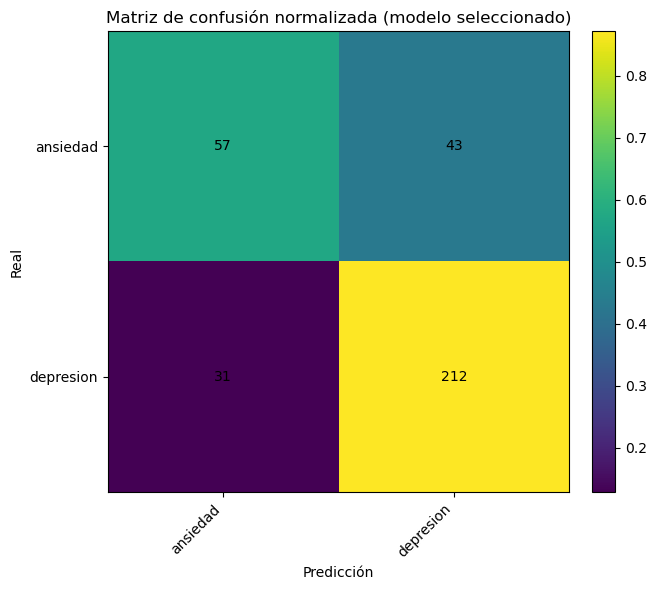

Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/matriz_confusion.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/figures/matriz_confusion.png


In [5]:
# Matriz de confusión del modelo seleccionado
labels = sorted(pd.Series(list(set(df['y_true']) | set(df['y_pred']))).astype(str).unique())
cm = confusion_matrix(df['y_true'].astype(str), df['y_pred'].astype(str), labels=labels)
cmn = confusion_matrix(df['y_true'].astype(str), df['y_pred'].astype(str), labels=labels, normalize='true')

cm_csv = ERR_DIR / 'matriz_confusion.csv'
pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_csv)

plt.figure(figsize=(7, 6))
plt.imshow(cmn)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión normalizada (modelo seleccionado)')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
cm_fig = FIG_DIR / 'matriz_confusion.png'
plt.savefig(cm_fig, dpi=200)
plt.show()
print('Guardado:', cm_csv)
print('Guardado:', cm_fig)


In [6]:
# Términos distintivos en errores (unigramas)
stop_words = [
    'de','la','que','el','en','y','a','los','se','del','las','un','por','con','no','una','su','para','es','al',
    'lo','como','mas','pero','sus','le','ya','o','fue','este','ha','me','si','sin','sobre','tambien','hasta','son'
]

def top_unigramas(textos, top_k=30):
    textos = [t for t in textos if isinstance(t, str) and t.strip()]
    if not textos:
        return pd.DataFrame(columns=['termino', 'conteo'])
    vec = CountVectorizer(ngram_range=(1, 1), stop_words=stop_words)
    bag = vec.fit_transform(textos)
    freqs = np.asarray(bag.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    idx = np.argsort(freqs)[::-1][:top_k]
    return pd.DataFrame({'termino': terms[idx], 'conteo': freqs[idx]})

rows = []
for clase in sorted(df['y_true'].astype(str).unique()):
    fn = df[(df['y_true'].astype(str) == clase) & (df['y_pred'].astype(str) != clase)]
    fp = df[(df['y_true'].astype(str) != clase) & (df['y_pred'].astype(str) == clase)]

    top_fn = top_unigramas(fn.get('texto', pd.Series(dtype=str)).tolist(), top_k=30)
    top_fn['tipo_error'] = 'FN'
    top_fn['clase_objetivo'] = clase

    top_fp = top_unigramas(fp.get('texto', pd.Series(dtype=str)).tolist(), top_k=30)
    top_fp['tipo_error'] = 'FP'
    top_fp['clase_objetivo'] = clase

    rows.append(top_fn)
    rows.append(top_fp)

terms_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['termino','conteo','tipo_error','clase_objetivo'])
terms_path = ERR_DIR / 'terminos_distintivos_errores.csv'
terms_df.to_csv(terms_path, index=False)
print('Guardado:', terms_path)


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/terminos_distintivos_errores.csv


In [7]:
# Casos mal clasificados para revisión clínica
errores_df = df[df['error'] == 1].copy()
cols_show = [c for c in ['row_id', 'y_true', 'y_pred', 'etiqueta', 'texto', 'patient_id'] if c in errores_df.columns]
casos_path = ERR_DIR / 'casos_mal_clasificados.csv'
errores_df[cols_show].to_csv(casos_path, index=False)
print('Guardado:', casos_path)
print('Total casos mal clasificados:', len(errores_df))


Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/casos_mal_clasificados.csv
Total casos mal clasificados: 74


In [8]:
# Resumen de ejecución en JSON
summary = {
    'train_run_id_origen': TRAIN_RUN_ID,
    'predicciones_analizadas': pred_path.name,
    'n_total': int(len(df)),
    'tasa_error_global': float(df['error'].mean()),
}

summary_path = ERR_DIR / 'resumen_error_analysis.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Resumen guardado:', summary_path)
print('Análisis de errores finalizado.')


Resumen guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/error_analysis_20260512_172435/resumen_error_analysis.json
Análisis de errores finalizado.


## Capa clínica adicional para revisión externa

Este notebook exporta el material crudo de error analysis del modelo final en `dev`.
La curación clínica posterior puede organizarse en `10_validacion_clinica_ips.ipynb`, donde los errores se agrupan explícitamente en:

- `ansiedad→depresion`;
- `depresion→ansiedad`;
- casos de frontera ambigua;
- notas de seguimiento o baja especificidad diagnóstica;
- posibles casos que conviene discutir por ruido de etiquetado o por solapamiento clínico.

La idea es separar dos niveles:

1. `09`: trazabilidad y export del error analysis alineado al modelo congelado;
2. `10`: lectura clínica externa y preparación de material reusable para revisión clínica y futura xAI.


## Cierre dev ensamble: análisis de errores alineado

Esta sección agrega el análisis de errores del ensamble formalizado en `dev`, sin reemplazar el análisis histórico del híbrido tabular. Se trabaja solo con artefactos ya generados por `04c` y `08`, y se exportan archivos dentro de la carpeta oficial `data/outputs/cierre_dev_ensamble_<timestamp>/`.

Decisiones de trazabilidad:

- no se abre `test`;
- no se reentrena ningún modelo;
- no se modifican reglas clínicas;
- el CSV principal de errores no incluye texto clínico libre para evitar exponer PHI;
- la comparación central es contra el `ROBERTA_CLINICAL` standalone con el mismo `max_length` de la rama contextual del ensamble.


In [9]:
# Análisis de errores del ensamble alineado en dev.
# Esta celda es deliberadamente autocontenida para que el cierre pueda reproducirse
# desde el notebook sin depender de scripts sueltos. No reentrena modelos.

from sklearn.metrics import classification_report

LABELS = ['ansiedad', 'depresion']

def resolver_cierre_ensamble():
    """Ubica la carpeta oficial del cierre del ensamble.

    Prioridad:
    1. CIERRE_DEV_ENSAMBLE_DIR si se pasa una ruta explícita.
    2. CIERRE_DEV_ENSAMBLE_RUN_ID si se pasa el nombre de la corrida.
    3. Última carpeta data/outputs/cierre_dev_ensamble_*.
    """
    env_dir = os.getenv('CIERRE_DEV_ENSAMBLE_DIR')
    if env_dir:
        d = Path(env_dir)
        if not d.exists():
            raise FileNotFoundError(f'CIERRE_DEV_ENSAMBLE_DIR no existe: {d}')
        return d

    env_run = os.getenv('CIERRE_DEV_ENSAMBLE_RUN_ID')
    if env_run:
        d = OUTPUTS_PATH / env_run
        if not d.exists():
            raise FileNotFoundError(f'CIERRE_DEV_ENSAMBLE_RUN_ID no existe en outputs: {d}')
        return d

    cierres = sorted(
        [p for p in OUTPUTS_PATH.glob('cierre_dev_ensamble_*') if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
    )
    if not cierres:
        raise FileNotFoundError('No se encontraron carpetas cierre_dev_ensamble_* en data/outputs.')
    return cierres[-1]

CIERRE_ENS_DIR = resolver_cierre_ensamble()
print('CIERRE_ENS_DIR:', CIERRE_ENS_DIR)

pred_ens_path = CIERRE_ENS_DIR / 'predicciones_ensamble_dev.csv'
pred_rob_path = DATA_PATH / 'roberta_clinical_predicciones_dev.csv'
pred_tfidf_path = DATA_PATH / 'tfidf_predicciones_dev.csv'
dev_path = SPLITS_PATH / 'dev_denoised.csv'

for required in [pred_ens_path, pred_rob_path, dev_path]:
    if not required.exists():
        raise FileNotFoundError(required)

pred_ens = pd.read_csv(pred_ens_path)
pred_rob = pd.read_csv(pred_rob_path)
dev_df = pd.read_csv(dev_path)
pred_tfidf = pd.read_csv(pred_tfidf_path) if pred_tfidf_path.exists() else None

ctx_pred_cols = [c for c in pred_ens.columns if c.startswith('y_pred__ctx_roberta_clinical_')]
if len(ctx_pred_cols) != 1:
    raise ValueError(f'No se pudo identificar una única rama contextual ROBERTA_CLINICAL: {ctx_pred_cols}')
ctx_pred_col = ctx_pred_cols[0]
CTX_KEY = ctx_pred_col.replace('y_pred__', '')
try:
    CTX_MAX_LENGTH = int(CTX_KEY.rsplit('_', 1)[-1])
except Exception:
    CTX_MAX_LENGTH = None
ROBERTA_LABEL = f'ROBERTA_CLINICAL {CTX_MAX_LENGTH}' if CTX_MAX_LENGTH else 'ROBERTA_CLINICAL'

# Validación estricta de comparabilidad: mismo row_id, mismo orden y misma y_true.
def validar_predicciones(nombre, df_pred, base):
    req = {'row_id', 'y_true', 'y_pred'}
    if not req.issubset(df_pred.columns):
        raise ValueError(f'{nombre} no contiene columnas requeridas: {sorted(req)}')
    if len(df_pred) != len(base):
        raise ValueError(f'{nombre} tiene n={len(df_pred)}, dev tiene n={len(base)}')
    if not df_pred['row_id'].equals(base['row_id']):
        raise ValueError(f'{nombre} no conserva el mismo orden de row_id que dev.')
    if not df_pred['y_true'].astype(str).equals(base['etiqueta'].astype(str)):
        raise ValueError(f'{nombre} no conserva la misma etiqueta real que dev.')

validar_predicciones('ensamble', pred_ens, dev_df)
validar_predicciones(ROBERTA_LABEL, pred_rob, dev_df)
if pred_tfidf is not None:
    validar_predicciones('TF-IDF', pred_tfidf, dev_df)

sym_py_col = 'y_pred__simbolico_py_rf'
sym_llm_col = 'y_pred__simbolico_core_rf_late_fusion_llm'
for col in [ctx_pred_col, sym_py_col, sym_llm_col]:
    if col not in pred_ens.columns:
        raise ValueError(f'Predicciones de ensamble no contienen columna esperada: {col}')

# Unión mínima para análisis. No se exporta texto clínico libre en el CSV principal.
analysis_df = pred_ens[[
    'row_id', 'y_true', 'y_pred', 'prob_ansiedad', 'prob_depresion',
    ctx_pred_col, sym_py_col, sym_llm_col,
]].rename(columns={
    'y_true': 'label_real',
    'y_pred': 'prediccion_ensamble',
    'prob_ansiedad': 'prob_ansiedad_ensamble',
    'prob_depresion': 'prob_depresion_ensamble',
    ctx_pred_col: 'prediccion_rama_contextual_roberta',
    sym_py_col: 'prediccion_rama_simbolica_py_rf',
    sym_llm_col: 'prediccion_rama_simbolica_core_late_fusion',
})

rob_cols = pred_rob[['row_id', 'y_pred', 'prob_ansiedad', 'prob_depresion']].rename(columns={
    'y_pred': 'prediccion_roberta',
    'prob_ansiedad': 'prob_ansiedad_roberta',
    'prob_depresion': 'prob_depresion_roberta',
})
analysis_df = analysis_df.merge(rob_cols, on='row_id', how='left')

if pred_tfidf is not None:
    tfidf_cols = pred_tfidf[['row_id', 'y_pred']].rename(columns={'y_pred': 'prediccion_tfidf'})
    analysis_df = analysis_df.merge(tfidf_cols, on='row_id', how='left')
else:
    analysis_df['prediccion_tfidf'] = pd.NA

# Señales de soporte para lectura: margen, confianza y acuerdo entre ramas.
branch_pred_cols = [
    'prediccion_rama_contextual_roberta',
    'prediccion_rama_simbolica_py_rf',
    'prediccion_rama_simbolica_core_late_fusion',
]
analysis_df['margen_ensamble'] = (
    analysis_df['prob_ansiedad_ensamble'] - analysis_df['prob_depresion_ensamble']
).abs()
analysis_df['confianza_ensamble'] = analysis_df[['prob_ansiedad_ensamble', 'prob_depresion_ensamble']].max(axis=1)
analysis_df['acuerdo_ramas_n'] = analysis_df.apply(
    lambda r: sum(str(r[c]) == str(r['prediccion_ensamble']) for c in branch_pred_cols),
    axis=1,
)
analysis_df['ensamble_correcto'] = analysis_df['label_real'].astype(str) == analysis_df['prediccion_ensamble'].astype(str)
analysis_df['roberta_correcto'] = analysis_df['label_real'].astype(str) == analysis_df['prediccion_roberta'].astype(str)
analysis_df['tfidf_correcto'] = analysis_df['label_real'].astype(str) == analysis_df['prediccion_tfidf'].astype(str)

def tipo_error(row):
    if row['ensamble_correcto']:
        return 'correcto'
    return f"{row['label_real']}→{row['prediccion_ensamble']}"

def observacion(row):
    if row['ensamble_correcto'] and not row['roberta_correcto']:
        return f'ensamble corrige a {ROBERTA_LABEL}'
    if not row['ensamble_correcto'] and row['roberta_correcto']:
        return f'ensamble introduce error frente a {ROBERTA_LABEL}'
    if not row['ensamble_correcto'] and not row['roberta_correcto']:
        if str(row['prediccion_ensamble']) == str(row['prediccion_roberta']):
            return f'error compartido con {ROBERTA_LABEL}'
        return 'ambos erran, con predicción distinta'
    if row['ensamble_correcto'] and row['acuerdo_ramas_n'] == len(branch_pred_cols):
        return 'correcto con acuerdo completo de ramas'
    return 'correcto con desacuerdo parcial de ramas'

analysis_df['tipo_error'] = analysis_df.apply(tipo_error, axis=1)
analysis_df['observacion_breve'] = analysis_df.apply(observacion, axis=1)

error_cols = [
    'row_id', 'label_real', 'prediccion_ensamble',
    'prob_ansiedad_ensamble', 'prob_depresion_ensamble',
    'prediccion_roberta', 'prob_ansiedad_roberta', 'prob_depresion_roberta',
    'prediccion_tfidf', 'tipo_error', 'observacion_breve',
    'prediccion_rama_contextual_roberta', 'prediccion_rama_simbolica_py_rf',
    'prediccion_rama_simbolica_core_late_fusion', 'acuerdo_ramas_n',
    'margen_ensamble', 'confianza_ensamble',
]
errores_path = CIERRE_ENS_DIR / 'errores_ensamble_dev.csv'
analysis_df[error_cols].to_csv(errores_path, index=False)

solo_errores_path = CIERRE_ENS_DIR / 'solo_errores_ensamble_dev.csv'
analysis_df.loc[~analysis_df['ensamble_correcto'], error_cols].to_csv(solo_errores_path, index=False)

# Comparación de errores contra ROBERTA_CLINICAL alineado y TF-IDF.
def resumen_modelo(nombre, pred_col):
    y_true = analysis_df['label_real'].astype(str)
    y_pred = analysis_df[pred_col].astype(str)
    rep = classification_report(y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0)
    return {
        'modelo': nombre,
        'n_eval': int(len(analysis_df)),
        'n_errores': int((y_true != y_pred).sum()),
        'tasa_error': float((y_true != y_pred).mean()),
        'macro_f1': float(rep['macro avg']['f1-score']),
        'weighted_f1': float(rep['weighted avg']['f1-score']),
        'f1_ansiedad': float(rep['ansiedad']['f1-score']),
        'f1_depresion': float(rep['depresion']['f1-score']),
        'recall_ansiedad': float(rep['ansiedad']['recall']),
        'recall_depresion': float(rep['depresion']['recall']),
    }

resumen_rows = [
    resumen_modelo(f'ensamble_weighted_soft_{CTX_MAX_LENGTH}', 'prediccion_ensamble'),
    resumen_modelo(f'roberta_clinical_{CTX_MAX_LENGTH}', 'prediccion_roberta'),
]
if pred_tfidf is not None:
    resumen_rows.append(resumen_modelo('tfidf', 'prediccion_tfidf'))
resumen_errores = pd.DataFrame(resumen_rows)
resumen_errores_path = CIERRE_ENS_DIR / 'resumen_errores_modelos_dev.csv'
resumen_errores.to_csv(resumen_errores_path, index=False)

interseccion_rows = [
    {'categoria': 'ambos_correctos_ensamble_y_roberta', 'n': int((analysis_df['ensamble_correcto'] & analysis_df['roberta_correcto']).sum())},
    {'categoria': 'ensamble_corrige_roberta', 'n': int((analysis_df['ensamble_correcto'] & ~analysis_df['roberta_correcto']).sum())},
    {'categoria': 'roberta_corrige_ensamble', 'n': int((~analysis_df['ensamble_correcto'] & analysis_df['roberta_correcto']).sum())},
    {'categoria': 'ambos_erran_misma_prediccion', 'n': int(((~analysis_df['ensamble_correcto']) & (~analysis_df['roberta_correcto']) & (analysis_df['prediccion_ensamble'] == analysis_df['prediccion_roberta'])).sum())},
    {'categoria': 'ambos_erran_prediccion_distinta', 'n': int(((~analysis_df['ensamble_correcto']) & (~analysis_df['roberta_correcto']) & (analysis_df['prediccion_ensamble'] != analysis_df['prediccion_roberta'])).sum())},
]
interseccion_df = pd.DataFrame(interseccion_rows)
interseccion_path = CIERRE_ENS_DIR / 'comparacion_errores_ensamble_vs_roberta.csv'
interseccion_df.to_csv(interseccion_path, index=False)

# Casos A/B/C propuestos para revisión cualitativa, sin texto clínico libre.
def tomar_casos(mask, categoria, criterio):
    subset = analysis_df.loc[mask].copy()
    if subset.empty:
        return subset
    subset['caso_abc'] = categoria
    subset['criterio_seleccion'] = criterio
    return subset.sort_values(['confianza_ensamble', 'margen_ensamble'], ascending=False).head(5)

casos_abc = pd.concat([
    tomar_casos(analysis_df['ensamble_correcto'] & ~analysis_df['roberta_correcto'], 'A_ensamble_corrige_roberta', f'ensamble acierta y {ROBERTA_LABEL} falla'),
    tomar_casos(~analysis_df['ensamble_correcto'] & analysis_df['roberta_correcto'], 'B_roberta_corrige_ensamble', f'{ROBERTA_LABEL} acierta y ensamble falla'),
    tomar_casos(~analysis_df['ensamble_correcto'] & ~analysis_df['roberta_correcto'], 'C_error_compartido', 'ambos modelos fallan; caso útil para discusión clínica'),
], ignore_index=True)
casos_abc_cols = ['caso_abc', 'criterio_seleccion'] + error_cols
casos_abc_path = CIERRE_ENS_DIR / 'casos_abc_ensamble_dev.csv'
casos_abc[casos_abc_cols].to_csv(casos_abc_path, index=False)

ens_metrics = resumen_errores.loc[resumen_errores['modelo'].eq(f'ensamble_weighted_soft_{CTX_MAX_LENGTH}')].iloc[0]
rob_metrics = resumen_errores.loc[resumen_errores['modelo'].eq(f'roberta_clinical_{CTX_MAX_LENGTH}')].iloc[0]
ens_err = int(ens_metrics['n_errores'])
rob_err = int(rob_metrics['n_errores'])
ens_corrige = int((analysis_df['ensamble_correcto'] & ~analysis_df['roberta_correcto']).sum())
rob_corrige = int((~analysis_df['ensamble_correcto'] & analysis_df['roberta_correcto']).sum())
ambos_erran = int((~analysis_df['ensamble_correcto'] & ~analysis_df['roberta_correcto']).sum())
ensamble_supera_roberta = bool((ens_metrics['macro_f1'] >= rob_metrics['macro_f1']) and (ens_err <= rob_err))

lectura = [
    '# Análisis de errores del ensamble en dev',
    '',
    '## Resumen',
    '',
    f'- Registros evaluados: `{len(analysis_df)}`.',
    f'- `max_length` contextual evaluado: `{CTX_MAX_LENGTH}`.',
    f'- Errores del ensamble weighted soft: `{ens_err}`.',
    f'- Errores de {ROBERTA_LABEL}: `{rob_err}`.',
    f'- Casos donde el ensamble corrige a {ROBERTA_LABEL}: `{ens_corrige}`.',
    f'- Casos donde {ROBERTA_LABEL} corrige al ensamble: `{rob_corrige}`.',
    f'- Casos donde ambos fallan: `{ambos_erran}`.',
    '',
    '## Lectura',
    '',
]
if ens_err < rob_err:
    lectura.append(f'El análisis de errores muestra que el ensamble reduce errores frente a `{ROBERTA_LABEL}` en esta corrida alineada.')
elif ens_err > rob_err:
    lectura.append(f'El análisis de errores confirma que el ensamble introduce más errores que `{ROBERTA_LABEL}` en esta corrida alineada.')
else:
    lectura.append(f'El análisis de errores muestra la misma cantidad total de errores que `{ROBERTA_LABEL}`.')
if ensamble_supera_roberta:
    lectura.append('La evidencia cuantitativa y el análisis de errores respaldan adoptar el ensamble como cierre dev alineado.')
else:
    lectura.append('La evidencia cuantitativa y el análisis de errores no respaldan adoptar el ensamble por encima del Transformer contextual alineado.')
lectura.extend([
    'Ansiedad sigue siendo la clase más difícil y debe interpretarse con macro-F1, balanced accuracy y matriz de confusión.',
    '',
    '## Archivos exportados',
    '',
    f'- `{errores_path.name}`: predicción por fila, probabilidades y observación breve, sin texto clínico libre.',
    f'- `{solo_errores_path.name}`: subconjunto de errores del ensamble.',
    f'- `{resumen_errores_path.name}`: resumen comparativo de errores y métricas por modelo.',
    f'- `{interseccion_path.name}`: intersección de errores ensamble vs ROBERTA_CLINICAL alineado.',
    f'- `{casos_abc_path.name}`: casos A/B/C propuestos para revisión cualitativa, sin texto clínico libre.',
])

reporte_errores_path = CIERRE_ENS_DIR / 'reporte_analisis_errores_ensamble_dev.md'
reporte_errores_path.write_text('\n'.join(lectura) + '\n', encoding='utf-8')

# Actualizar estados controlados de la tabla canónica según evidencia final.
def actualizar_estados_cierre(path_csv):
    if not path_csv.exists():
        return None
    df_status = pd.read_csv(path_csv)
    if 'experimento' not in df_status.columns or 'estado' not in df_status.columns:
        return None
    mask_roberta = df_status['experimento'].astype(str).eq(f'ROBERTA_CLINICAL standalone max_length {CTX_MAX_LENGTH}')
    mask_ensamble = df_status['experimento'].astype(str).str.startswith(f'Ensamble weighted soft ROBERTA_CLINICAL {CTX_MAX_LENGTH}')
    if ensamble_supera_roberta:
        df_status.loc[mask_ensamble, 'estado'] = 'principal'
        df_status.loc[mask_roberta, 'estado'] = 'comparativo'
    else:
        df_status.loc[mask_roberta, 'estado'] = 'principal'
        df_status.loc[mask_ensamble, 'estado'] = 'control_metodologico'
    df_status.to_csv(path_csv, index=False)
    return df_status

tabla_actualizada = actualizar_estados_cierre(CIERRE_ENS_DIR / 'tabla_experimentos_dev_cierre.csv')
actualizar_estados_cierre(CIERRE_ENS_DIR / 'metricas_comparativas_dev.csv')

# Actualizar manifest y reporte del cierre con rutas y veredicto.
manifest_path = CIERRE_ENS_DIR / 'manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    manifest.setdefault('paths', {})
    manifest['paths'].update({
        'errores_ensamble': str(errores_path),
        'solo_errores_ensamble': str(solo_errores_path),
        'resumen_errores_modelos': str(resumen_errores_path),
        'comparacion_errores_ensamble_vs_roberta': str(interseccion_path),
        'casos_abc_ensamble': str(casos_abc_path),
        'reporte_analisis_errores_ensamble': str(reporte_errores_path),
    })
    ejecutados = manifest.setdefault('notebooks_scripts_ejecutados', [])
    nb_name = 'notebooks/analysis/09_analisis_errores_hibrido.ipynb'
    if nb_name not in ejecutados:
        ejecutados.append(nb_name)
    notebooks_md_path = CIERRE_ENS_DIR / 'notebooks_scripts_ejecutados.md'
    if notebooks_md_path.exists():
        notebooks_md = notebooks_md_path.read_text(encoding='utf-8')
        linea_nb = '- `notebooks/analysis/09_analisis_errores_hibrido.ipynb`: completa análisis de errores del ensamble 512 y actualiza veredicto.'
        if linea_nb not in notebooks_md:
            notebooks_md = notebooks_md.replace('\nNo se ejecutó `test`.', f'\n{linea_nb}\n\nNo se ejecutó `test`.')
            notebooks_md_path.write_text(notebooks_md, encoding='utf-8')
    if ensamble_supera_roberta:
        manifest['veredicto_error_analysis'] = f'el ensamble reduce errores frente a {ROBERTA_LABEL}; recomendado como nuevo cierre dev alineado'
        manifest['veredicto'] = 'nuevo cierre dev recomendado por métricas y análisis de errores en dev; TEST_VIRGEN'
    else:
        manifest['veredicto_error_analysis'] = f'el ensamble no reduce errores frente a {ROBERTA_LABEL}; recomendar Transformer contextual alineado salvo decisión metodológica distinta'
        manifest['veredicto'] = 'candidato formal evaluado; no recomendado como nuevo cierre dev frente al Transformer contextual alineado'
    manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')

reporte_cierre_path = CIERRE_ENS_DIR / 'reporte_cierre_dev_ensamble.md'
if reporte_cierre_path.exists():
    reporte = reporte_cierre_path.read_text(encoding='utf-8')
    if ensamble_supera_roberta:
        reporte = reporte.replace(
            f'Resultado generado como **candidato formal de cierre en dev** con `max_length={CTX_MAX_LENGTH}`. No se abre `test`.',
            f'Resultado recomendado como **nuevo cierre dev** con `max_length={CTX_MAX_LENGTH}`, luego de métricas, matrices de confusión y análisis de errores en `dev`. No se abre `test`.',
        )
        reporte = reporte.replace(
            f'## Pendiente antes de llamarlo nuevo cierre dev\n\n- Completar análisis de errores del ensamble y comparación contra `ROBERTA_CLINICAL {CTX_MAX_LENGTH}`.\n',
            '',
        )
        # Limpieza robusta del bloque pendiente heredado de 08. La ejecución de
        # este notebook ya completa el análisis de errores, por lo que ese bloque
        # no debe quedar en el reporte final aunque cambie levemente el texto.
        pendiente_ini = reporte.find('## Pendiente antes de llamarlo nuevo cierre dev')
        if pendiente_ini != -1:
            siguiente_heading = reporte.find('\n## ', pendiente_ini + 1)
            if siguiente_heading != -1:
                reporte = reporte[:pendiente_ini].rstrip() + '\n\n' + reporte[siguiente_heading + 1:]
            else:
                reporte = reporte[:pendiente_ini].rstrip() + '\n'
    if tabla_actualizada is not None:
        cols_tabla = ['experimento', 'estado', 'n_eval', 'macro_f1', 'balanced_accuracy', 'weighted_f1', 'f1_ansiedad', 'f1_depresion']
        tabla_md = tabla_actualizada[cols_tabla].to_markdown(index=False)
        ini = reporte.find('## Tabla comparativa')
        fin = reporte.find('## Lectura por clase')
        if ini != -1 and fin != -1 and fin > ini:
            reporte = reporte[:ini] + '## Tabla comparativa\n\n' + tabla_md + '\n\n' + reporte[fin:]

    if ensamble_supera_roberta:
        veredicto_texto = f'El análisis de errores fue completado. Con la evidencia actual, se recomienda adoptar el ensamble como **nuevo cierre dev** frente a `{ROBERTA_LABEL}`.'
        lectura_final = f'- Lectura: el análisis de errores respalda adoptar el ensamble como mejora principal frente a `{ROBERTA_LABEL}` en el cierre alineado.'
    else:
        veredicto_texto = f'El análisis de errores fue completado. Con la evidencia actual, no se recomienda adoptar el ensamble como nuevo cierre dev por encima de `{ROBERTA_LABEL}`.'
        lectura_final = f'- Lectura: el análisis de errores no respalda adoptar el ensamble como mejora principal frente a `{ROBERTA_LABEL}` en el cierre alineado.'

    bloque = '\n'.join([
        '',
        '## Veredicto posterior al análisis de errores',
        '',
        veredicto_texto,
        '',
        '## Análisis de errores posterior',
        '',
        f'- Errores del ensamble weighted soft: `{ens_err}`.',
        f'- Errores de `{ROBERTA_LABEL}`: `{rob_err}`.',
        f'- El ensamble corrige a ROBERTA en `{ens_corrige}` casos, y ROBERTA corrige al ensamble en `{rob_corrige}` casos.',
        f'- Ambos fallan en `{ambos_erran}` casos.',
        lectura_final,
        f'- Reporte específico: `{reporte_errores_path}`.',
    ])
    corte = reporte.find('## Veredicto posterior al análisis de errores')
    if corte != -1:
        reporte = reporte[:corte].rstrip() + '\n' + bloque + '\n'
    else:
        reporte = reporte.rstrip() + '\n' + bloque + '\n'
    reporte_cierre_path.write_text(reporte, encoding='utf-8')

print('Guardado:', errores_path)
print('Guardado:', solo_errores_path)
print('Guardado:', resumen_errores_path)
print('Guardado:', interseccion_path)
print('Guardado:', casos_abc_path)
print('Guardado:', reporte_errores_path)
print('Veredicto ensamble_supera_roberta:', ensamble_supera_roberta)
display(resumen_errores)
display(interseccion_df)


CIERRE_ENS_DIR: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/errores_ensamble_dev.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/solo_errores_ensamble_dev.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/resumen_errores_modelos_dev.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/comparacion_errores_ensamble_vs_roberta.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/casos_abc_ensamble_dev.csv
Guardado: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/data/outputs/cierre_dev_ensamble_512_20260512_155606/reporte_an

,modelo,n_eval,n_errores,tasa_error,macro_f1,weighted_f1,f1_ansiedad,f1_depresion,recall_ansiedad,recall_depresion
0,ensamble_weighted_soft_512,343,76,0.221574,0.749250,0.784909,0.663717,0.834783,0.75,0.790123
1,roberta_clinical_512,343,79,0.230321,0.741078,0.776955,0.655022,0.827133,0.75,0.777778
2,tfidf,343,80,0.233236,0.740564,0.774936,0.658120,0.823009,0.77,0.765432


,categoria,n
0,ambos_correctos_ensamble_y_roberta,264
1,ensamble_corrige_roberta,3
2,roberta_corrige_ensamble,0
3,ambos_erran_misma_prediccion,76
4,ambos_erran_prediccion_distinta,0
